In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load Data

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalisasi
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Shape x_train:", x_train.shape)
print("Shape y_train:", y_train.shape)
print("Shape x_test :", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4029s 24us/step
Shape x_train: (50000, 32, 32, 3)
Shape y_train: (50000, 10)
Shape x_test : (10000, 32, 32, 3)


# Pembuatan Base Model

In [ ]:
def build_model(optimizer):
  model = Sequential([
      Input(shape=(32, 32, 3)),

      tf.keras.layers.RandomFlip("horizontal"),
      tf.keras.layers.RandomRotation(0.05),
      tf.keras.layers.RandomZoom(0.1),

      Conv2D(32, (3, 3), activation='relu', padding='same'),
      BatchNormalization(),
      MaxPooling2D(2, 2),
      Dropout(0.25),

      Conv2D(64, (3, 3), activation='relu', padding='same'),
      BatchNormalization(),
      MaxPooling2D(2, 2),
      Dropout(0.25),

      Conv2D(128, (3, 3), activation='relu', padding='same'),
      BatchNormalization(),
      MaxPooling2D(2, 2),
      Dropout(0.30),

      Flatten(),

      Dense(128, activation='relu'),
      BatchNormalization(),
      Dropout(0.50),

      Dense(10, activation='softmax')
  ])

  model.compile(
      optimizer=optimizer,
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  return model

In [ ]:
def build_transfer_model(optimizer):
  base_model = MobileNetV2(
      weights='imagenet',
      include_top=False,
      input_shape=(96, 96, 3)
  )

  base_model.trainable = False

  model = Sequential([
      Input(shape=(32, 32, 3)),

      tf.keras.layers.Resizing(96, 96),
      tf.keras.layers.Rescaling(scale=2.0, offset=-1.0),

      base_model,

      GlobalAveragePooling2D(),
      Dense(128, activation='relu'),
      BatchNormalization(),
      Dropout(0.50),
      Dense(10, activation='softmax')
  ])

  model.compile(
      optimizer=optimizer,
      loss='categorical_crossentropy',
      metrics=['accuracy']
  )

  return model

# Eksperimen Hyperparameter

In [ ]:
experiments = [
    {"name": "Adam_lr0.001_bs32",    "opt_name": "Adam",    "lr": 0.001,  "batch_size": 32, "epochs": 30},
    {"name": "Adam_lr0.0001_bs32",   "opt_name": "Adam",    "lr": 0.0001, "batch_size": 32, "epochs": 30},
    {"name": "Adam_lr0.001_bs64",    "opt_name": "Adam",    "lr": 0.001,  "batch_size": 64, "epochs": 30},
    {"name": "Adam_lr0.001_bs128",   "opt_name": "Adam",    "lr": 0.001,  "batch_size": 128,"epochs": 30},
    {"name": "SGD_lr0.01_bs32",      "opt_name": "SGD",     "lr": 0.01,   "batch_size": 32, "epochs": 30},
    {"name": "RMSprop_lr0.001_bs32", "opt_name": "RMSprop", "lr": 0.001,  "batch_size": 32, "epochs": 30},
]

# Factory untuk membuat optimizer baru setiap eksperimen
def make_optimizer(name, lr):
    if name == "Adam":
        return Adam(learning_rate=lr)
    elif name == "SGD":
        return SGD(learning_rate=lr)
    elif name == "RMSprop":
        return RMSprop(learning_rate=lr)
    else:
        raise ValueError(f"Optimizer tidak dikenal: {name}")
# Helper optimasi training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Training Model

In [ ]:
results = []
histories = {}   # simpan history untuk grafik

for exp in experiments:
    print("=" * 60)
    print("Training :", exp["name"])
    print("=" * 60)

    tf.random.set_seed(SEED)  # menyamakan titik awal setiap eksperimen

    optimizer = make_optimizer(exp["opt_name"], exp["lr"])
    model = build_model(optimizer)

    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        callbacks=[early_stop],
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    epochs_run = len(history.history['loss'])  # epoch aktual (bisa jadi < max karena EarlyStopping)

    results.append({
        "Model": exp["name"],
        "Optimizer": exp["opt_name"],
        "Learning Rate": exp["lr"],
        "Batch Size": exp["batch_size"],
        "Epoch (max)": exp["epochs"],
        "Epoch (aktual)": epochs_run,
        "Val Accuracy": round(max(history.history['val_accuracy']), 4),
        "Test Accuracy": round(test_acc, 4),
        "Test Loss": round(test_loss, 4),
    })

    histories[exp["name"]] = history

Training : Adam_lr0.001_bs32
Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.3925 - loss: 1.7685 - val_accuracy: 0.4697 - val_loss: 1.4733
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5050 - loss: 1.3753 - val_accuracy: 0.5814 - val_loss: 1.1834
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5523 - loss: 1.2573 - val_accuracy: 0.4920 - val_loss: 1.4349
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5824 - loss: 1.1784 - val_accuracy: 0.6019 - val_loss: 1.1231
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6033 - loss: 1.1266 - val_accuracy: 0.6113 - val_loss: 1.1138
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6236 - loss: 1.0740 - val_accuracy: 0.6529 - val_loss: 0.9887
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6366 - loss: 1.0380 - val_accuracy: 0.6337 - val_loss: 1.0725
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 1

# Hasil Hyperparameter Tunning

In [ ]:
df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print("\n=== TABEL HASIL HYPERPARAMETER TUNING ===")
print(df.to_string(index=False))
df.to_csv("hasil_hyperparameter_tuning.csv", index=False)


=== TABEL HASIL HYPERPARAMETER TUNING ===
               Model Optimizer  Learning Rate  Batch Size  Epoch (max)  Epoch (aktual)  Val Accuracy  Test Accuracy  Test Loss
   Adam_lr0.001_bs32      Adam         0.0010          32           30              18        0.7353         0.7338     0.7694
  Adam_lr0.0001_bs32      Adam         0.0001          32           30               6        0.5131         0.4299     1.6225
     SGD_lr0.01_bs32       SGD         0.0100          32           30               6        0.5529         0.4107     1.6333
RMSprop_lr0.001_bs32   RMSprop         0.0010          32           30               6        0.6778         0.3722     2.1267
   Adam_lr0.001_bs64      Adam         0.0010          64           30               6        0.6592         0.3676     1.9142
  Adam_lr0.001_bs128      Adam         0.0010         128           30               6        0.5982         0.2245     2.4614


# Visualisasi Perbandingan

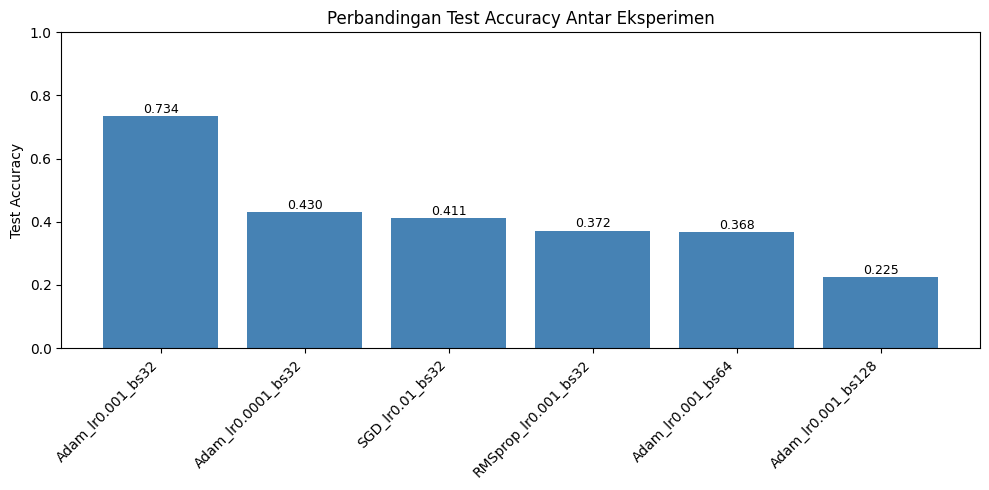

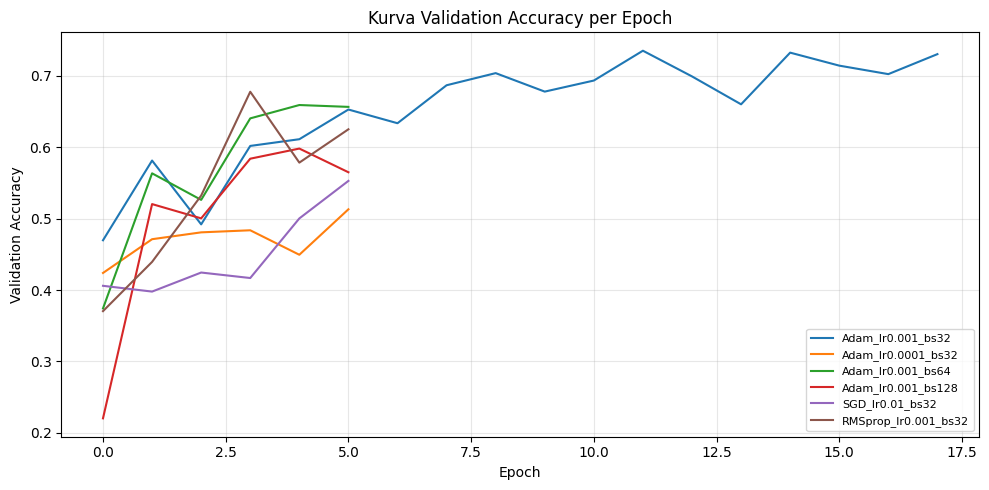

In [ ]:
# Bar chart Test Accuracy antar eksperimen
plt.figure(figsize=(10, 5))
plt.bar(df["Model"], df["Test Accuracy"], color='steelblue')
plt.title("Perbandingan Test Accuracy Antar Eksperimen")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
for i, v in enumerate(df["Test Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("perbandingan_test_accuracy.png", dpi=120)
plt.show()

# Kurva Validation Accuracy tiap eksperimen
plt.figure(figsize=(10, 5))
for name, hist in histories.items():
    plt.plot(hist.history['val_accuracy'], label=name)
plt.title("Kurva Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kurva_val_accuracy.png", dpi=120)
plt.show()

# Mount Model

In [ ]:
best_row = df.iloc[0]  # baris teratas = akurasi tertinggi
print("\n=== KONFIGURASI TERBAIK ===")
print(best_row.to_string())

# Cari konfigurasi asli dari daftar experiments
best_cfg = next(e for e in experiments if e["name"] == best_row["Model"])

# Latih ulang model terbaik pada seluruh data training
tf.random.set_seed(SEED)
best_optimizer = make_optimizer(best_cfg["opt_name"], best_cfg["lr"])
best_model = build_model(best_optimizer)

best_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=best_cfg["epochs"],
    batch_size=best_cfg["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

final_loss, final_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"\nModel terbaik ({best_cfg['name']}) -> Test Accuracy: {final_acc:.4f} | Test Loss: {final_loss:.4f}")

best_model.save("cnn_cifar10_best.keras")
print("Model terbaik disimpan sebagai: cnn_cifar10_best.keras")



=== KONFIGURASI TERBAIK ===
Model             Adam_lr0.001_bs32
Optimizer                      Adam
Learning Rate                 0.001
Batch Size                       32
Epoch (max)                      30
Epoch (aktual)                   18
Val Accuracy                 0.7353
Test Accuracy                0.7338
Test Loss                    0.7694
Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.3836 - loss: 1.7814 - val_accuracy: 0.4195 - val_loss: 1.5879
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.5003 - loss: 1.3970 - val_accuracy: 0.5483 - val_loss: 1.2795
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5419 - loss: 1.2871 - val_accuracy: 0.6260 - val_loss: 1.0585
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5718 - loss: 1.2090 - val_accuracy: 0.6444 - val_loss: 1.0204
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5939 - loss: 1.1514 - val_accuracy: 0.6076 - val_

In [ ]:
transfer_optimizer = Adam(learning_rate=0.001)

transfer_model = build_transfer_model(transfer_optimizer)

transfer_history = transfer_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

transfer_loss, transfer_acc = transfer_model.evaluate(x_test, y_test, verbose=0)

print(f"Transfer Learning MobileNetV2 -> Test Accuracy: {transfer_acc:.4f}")
print(f"Transfer Learning MobileNetV2 -> Test Loss: {transfer_loss:.4f}")

transfer_model.save("cnn_cifar10_transfer_mobilenetv2.keras")
print("Model transfer learning disimpan sebagai: cnn_cifar10_transfer_mobilenetv2.keras")

print(f"\n=== PERBANDINGAN FINAL ===")
print(f"Custom CNN        -> Test Accuracy: {final_acc:.4f}")
print(f"Transfer Learning -> Test Accuracy: {transfer_acc:.4f}")

if transfer_acc > final_acc:
    transfer_model.save("cnn_cifar10_best.keras")
    print(">>> Transfer Learning MobileNetV2 dipilih sebagai MODEL TERBAIK untuk deploy.")
else:
    print(">>> Custom CNN tetap dipilih sebagai MODEL TERBAIK untuk deploy.")

from google.colab import files
files.download("cnn_cifar10_best.keras")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 23ms/step - accuracy: 0.7902 - loss: 0.6421 - val_accuracy: 0.8530 - val_loss: 0.4156
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.8426 - loss: 0.4700 - val_accuracy: 0.8570 - val_loss: 0.4020
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.8548 - loss: 0.4336 - val_accuracy: 0.8610 - val_loss: 0.3977
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8639 - loss: 0.4067 - val_accuracy: 0.8589 - val_loss: 0.4003
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8669 - loss: 0.3928 - val_accuracy: 0.8629 - val_loss: 0.3941
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8727 - loss: 0.3781 - val_accuracy: 0.8649 - val_loss: 0.3925
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8766 - loss: 0.3652 - val_accuracy: 0.8588 - val_loss: 0.4059
Epoch 8/30
1250/1250 ━━━━━━

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>